# Epithelium-Safe Feature-Based Stroma Expert Correction

This notebook documents the `baseline_224` stroma correction experiment with colorectal adenocarcinoma epithelium preservation as a hard validation guardrail.

The goal is to improve cancer-associated stroma F2 without reducing epithelium recall or F2 relative to the frozen baseline on validation. The test split is evaluated only after the validation-selected system and thresholds are locked.

In [10]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import SVG, display

RUN_DIR = Path('../results/stroma_feature_experts')
MODEL_DIR = Path('../models/stroma_feature_experts')

metrics = json.loads((RUN_DIR / 'metrics.json').read_text())
selection = json.loads((RUN_DIR / 'selected_approach.json').read_text())
summary = pd.read_csv(RUN_DIR / 'stroma_metrics_summary.csv')

## 1. Approach

The baseline model is `baseline_224`. The trained 9-class CNN is frozen and used as a feature extractor; each expert receives the penultimate CNN vector plus low-risk auxiliary baseline outputs: the 9-class probabilities, confidence, stroma-vs-competitor margins, and entropy.

The three pairwise experts are trained only on original training samples from their two ground-truth classes:

| Expert | Competing class | Stroma class | Binary labels |
| --- | ---: | ---: | --- |
| debris vs stroma | 2 | 7 | 0 = debris, 1 = stroma |
| smooth muscle vs stroma | 5 | 7 | 0 = smooth muscle, 1 = stroma |
| epithelium vs stroma | 8 | 7 | 0 = epithelium, 1 = stroma |

The compared expert families are class-balanced logistic regression, calibrated linear SVM, calibrated RBF SVM, linear discriminant analysis, and a small weighted MLP.

## 2. Decision Rule

Inference starts from the baseline prediction. The baseline confidence gate is fixed at `0.90`: if baseline predicts debris, smooth muscle, or epithelium below that confidence, the matching expert may override the label.

The expert override has its own validation-tuned stroma score threshold. A low-confidence baseline epithelium prediction is changed to stroma only when the epithelium-vs-stroma expert score reaches the tuned threshold.

## 3. Selection Rule

Thresholds and approach selection are tuned on validation only. A candidate is eligible only if validation colorectal adenocarcinoma epithelium recall and F2 are both at least the baseline validation values. Among eligible candidates, the selected system maximizes validation stroma F2, preferring zero true-epithelium-to-stroma flips when scores tie.

Fallback order is explicit: full three-expert systems first, then debris plus smooth-muscle experts, then single experts, then baseline-only.

In [11]:
print('Selected approach:', metrics['selected_approach'])
print('Fallback group:', metrics['selected_fallback_group'])
print('Enabled experts:', metrics['enabled_experts'])
print('Baseline confidence gate:', metrics['baseline_confidence_gate'])
print('Expert thresholds:', metrics['final_thresholds'])
print('Validation epithelium guardrail passed:', metrics['validation_epithelium_guardrail_passed'])
print('Locked test epithelium preserved:', metrics['test_epithelium_preserved_after_locked_selection'])
summary

Selected approach: linear_svm
Fallback group: full_three_experts
Enabled experts: ['debris', 'smooth_muscle', 'epithelium']
Baseline confidence gate: 0.9
Expert thresholds: {'debris': 0.1, 'smooth_muscle': 0.3, 'epithelium': 0.5}
Validation epithelium guardrail passed: True
Locked test epithelium preserved: False


,split,system,stroma_precision,stroma_recall,stroma_f1,stroma_f2,epithelium_precision,epithelium_recall,epithelium_f1,epithelium_f2,changed_predictions,recovered_stroma_false_negatives,newly_introduced_stroma_false_positives,true_epithelium_changed_to_stroma
0,validation,baseline_only,0.968360,0.966507,0.967433,0.966877,0.984583,0.981145,0.982861,0.981831,0,0,0,0
1,validation,threshold_only,0.671855,0.991388,0.800928,0.905278,0.997502,0.836592,0.909989,0.864483,499,26,473,207
2,validation,logreg_expert_system,0.960037,0.988517,0.974069,0.982686,0.990832,0.981145,0.985965,0.983067,33,23,10,0
3,validation,linear_svm_expert_system,0.960930,0.988517,0.974528,0.982873,0.990134,0.981145,0.985619,0.982930,32,23,9,0
4,validation,rbf_svm_expert_system,0.966261,0.986603,0.976326,0.982466,0.990832,0.981145,0.985965,0.983067,24,21,3,0
5,validation,lda_expert_system,0.966825,0.976077,0.971429,0.974212,0.987351,0.981145,0.984238,0.982380,12,10,2,0
6,validation,mlp_expert_system,0.959070,0.986603,0.972642,0.980971,0.989437,0.981145,0.985273,0.982792,32,21,11,0
7,validation,final_selected_epithelium_safe_system,0.960930,0.988517,0.974528,0.982873,0.990134,0.981145,0.985619,0.982930,32,23,9,0
8,test,baseline_only,0.908714,0.520190,0.661631,0.568831,0.869472,0.988646,0.925237,0.962267,0,0,0,0
9,test,threshold_only,0.347341,0.961995,0.510397,0.710526,0.996258,0.863747,0.925282,0.887352,925,186,739,154


## 4. Validation Systems

These rows are validation results used for threshold and approach selection. Epithelium recall and F2 must not decrease relative to `baseline_only` for the final selected system.

In [12]:
summary[summary['split'] == 'validation'].sort_values(['system']).reset_index(drop=True)

,split,system,stroma_precision,stroma_recall,stroma_f1,stroma_f2,epithelium_precision,epithelium_recall,epithelium_f1,epithelium_f2,changed_predictions,recovered_stroma_false_negatives,newly_introduced_stroma_false_positives,true_epithelium_changed_to_stroma
0,validation,baseline_only,0.968360,0.966507,0.967433,0.966877,0.984583,0.981145,0.982861,0.981831,0,0,0,0
1,validation,final_selected_epithelium_safe_system,0.960930,0.988517,0.974528,0.982873,0.990134,0.981145,0.985619,0.982930,32,23,9,0
2,validation,lda_expert_system,0.966825,0.976077,0.971429,0.974212,0.987351,0.981145,0.984238,0.982380,12,10,2,0
3,validation,linear_svm_expert_system,0.960930,0.988517,0.974528,0.982873,0.990134,0.981145,0.985619,0.982930,32,23,9,0
4,validation,logreg_expert_system,0.960037,0.988517,0.974069,0.982686,0.990832,0.981145,0.985965,0.983067,33,23,10,0
5,validation,mlp_expert_system,0.959070,0.986603,0.972642,0.980971,0.989437,0.981145,0.985273,0.982792,32,21,11,0
6,validation,rbf_svm_expert_system,0.966261,0.986603,0.976326,0.982466,0.990832,0.981145,0.985965,0.983067,24,21,3,0
7,validation,threshold_only,0.671855,0.991388,0.800928,0.905278,0.997502,0.836592,0.909989,0.864483,499,26,473,207


## 5. Locked Test Evaluation

These rows are reported after validation selection. They show whether the locked system also preserved epithelium on test; test metrics are not used to select the expert family, thresholds, or fallback set.

In [13]:
summary[summary['split'] == 'test'].sort_values(['system']).reset_index(drop=True)

,split,system,stroma_precision,stroma_recall,stroma_f1,stroma_f2,epithelium_precision,epithelium_recall,epithelium_f1,epithelium_f2,changed_predictions,recovered_stroma_false_negatives,newly_introduced_stroma_false_positives,true_epithelium_changed_to_stroma
0,test,baseline_only,0.908714,0.520190,0.661631,0.568831,0.869472,0.988646,0.925237,0.962267,0,0,0,0
1,test,final_selected_epithelium_safe_system,0.568932,0.695962,0.626068,0.666212,0.871868,0.987835,0.926236,0.962237,274,74,200,1
2,test,lda_expert_system,0.784848,0.615202,0.689747,0.642999,0.877610,0.988646,0.929825,0.964246,89,40,49,0
3,test,linear_svm_expert_system,0.568932,0.695962,0.626068,0.666212,0.871868,0.987835,0.926236,0.962237,274,74,200,1
4,test,logreg_expert_system,0.659910,0.695962,0.677457,0.688440,0.875090,0.988646,0.928408,0.963636,203,74,129,0
5,test,mlp_expert_system,0.736077,0.722090,0.729017,0.724845,0.892387,0.988646,0.938053,0.967768,172,85,87,0
6,test,rbf_svm_expert_system,0.738693,0.698337,0.717949,0.706052,0.895511,0.987024,0.939043,0.967255,157,75,82,2
7,test,threshold_only,0.347341,0.961995,0.510397,0.710526,0.996258,0.863747,0.925282,0.887352,925,186,739,154


## 6. Accounting

The accounting fields show changed predictions per expert, recovered stroma false negatives, newly introduced stroma false positives, and true epithelium samples changed to stroma.

In [14]:
metrics['validation']['selected_accounting'], metrics['test']['corrected_accounting']

({'changed_predictions_per_expert': {'debris': 9,
   'smooth_muscle': 15,
   'epithelium': 8},
  'total_changed_predictions': 32,
  'recovered_stroma_false_negatives': 23,
  'newly_introduced_stroma_false_positives': 9,
  'true_epithelium_changed_to_stroma': 0,
  'remaining_stroma_false_negatives': 12},
 {'changed_predictions_per_expert': {'debris': 22,
   'smooth_muscle': 247,
   'epithelium': 5},
  'total_changed_predictions': 274,
  'recovered_stroma_false_negatives': 74,
  'newly_introduced_stroma_false_positives': 200,
  'true_epithelium_changed_to_stroma': 1,
  'remaining_stroma_false_negatives': 128})

## 7. Confusion Matrices

The generated artifacts include full confusion matrices for baseline, threshold-only, each trained expert system, and the final selected epithelium-safe system.

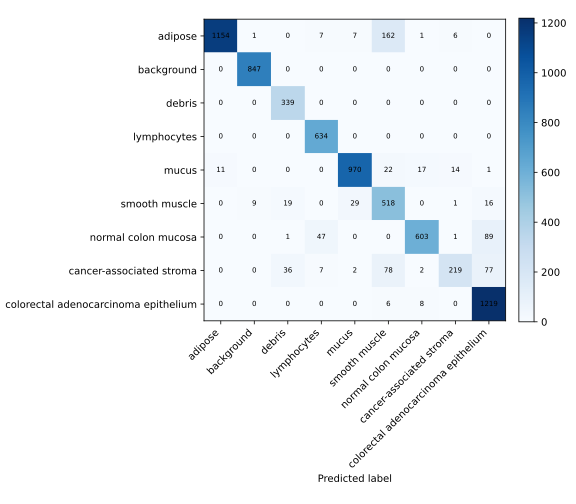

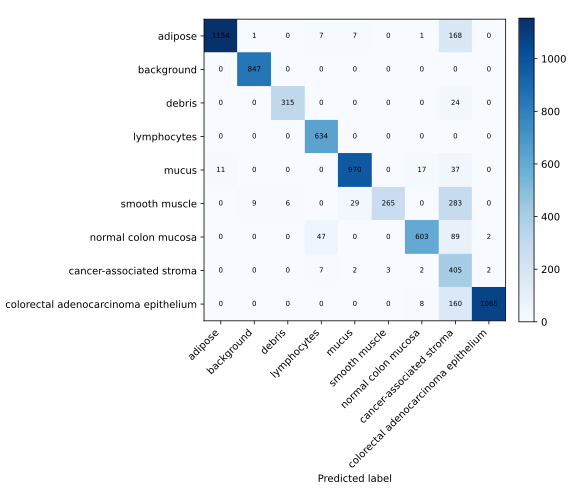

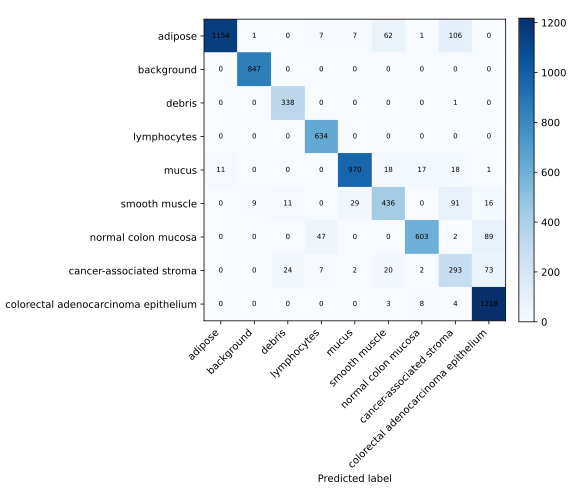

In [15]:
for name in ['confusion_matrix_baseline.svg', 'confusion_matrix_threshold_only.svg', 'confusion_matrix_feature_expert_correction.svg']:
    path = RUN_DIR / name
    if path.exists():
        display(SVG(filename=str(path)))